In [7]:
import numpy as np
import pandas as pd
import datetime
import yfinance as yf
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

# For importing universal scripts
import sys
import os
# Go up two levels from the subfolder
sys.path.append(os.path.abspath(".."))
from indicators_returns import final_df #Universal script for indicator set and actuals
import importlib
import indicators_returns
importlib.reload(indicators_returns)
from indicators_returns import final_df
import gc
from sklearn.metrics import (fbeta_score, accuracy_score, f1_score, 
                             confusion_matrix, balanced_accuracy_score, recall_score, matthews_corrcoef, precision_score)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split, StratifiedKFold
from xgboost import XGBClassifier
import math
import pickle

tags = pd.read_csv('../Indicator_Selection_Pipeline/Finalization/tags_cons.csv') 

def extract(ticker, returns, lb, cat_cols_all, windows=[10, 25]):

    import os
    # point this at an existing directory in your project
    os.chdir('/Users/brettchase/Documents/Fracturion/Feature_Set_Construction_Testing')
    
    df = final_df(ticker, returns, lb)
    df = df.iloc[:-101].replace([np.inf, -np.inf], 0)#

    df = df.sort_index(ascending=True)
    # Exponential Moving Average
    ema_cols = {
        f"{col}_EMA{w}": df[col].ewm(span=w, adjust=False).mean()
        for w in windows
        for col in cat_cols_all
    }
    # 3) merge them back into one dict
    new_cols = {**ema_cols}

    # 4) concatenate onto your original df
    df = pd.concat([df, pd.DataFrame(new_cols, index=df.index)], axis=1)    
    df = df.sort_index(ascending=False)
    
    return df

lb = 8
returns = [2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 25]
raw_all = tags['Indicator'][tags['Type'] == 'Raw'].tolist()
df = extract('QQQ', returns, lb, raw_all, windows=[10,25])

0.2   -1.3
0.4   -0.1
0.6    0.7
0.8    1.6
Name: Return%_2, dtype: float64


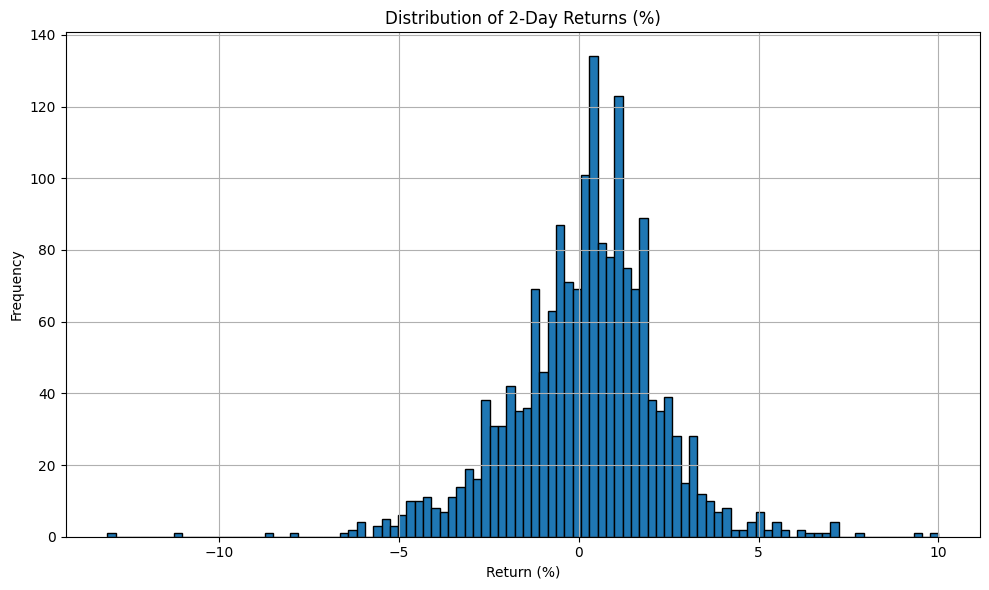

0.2   -1.5
0.4   -0.1
0.6    0.9
0.8    2.0
Name: Return%_3, dtype: float64


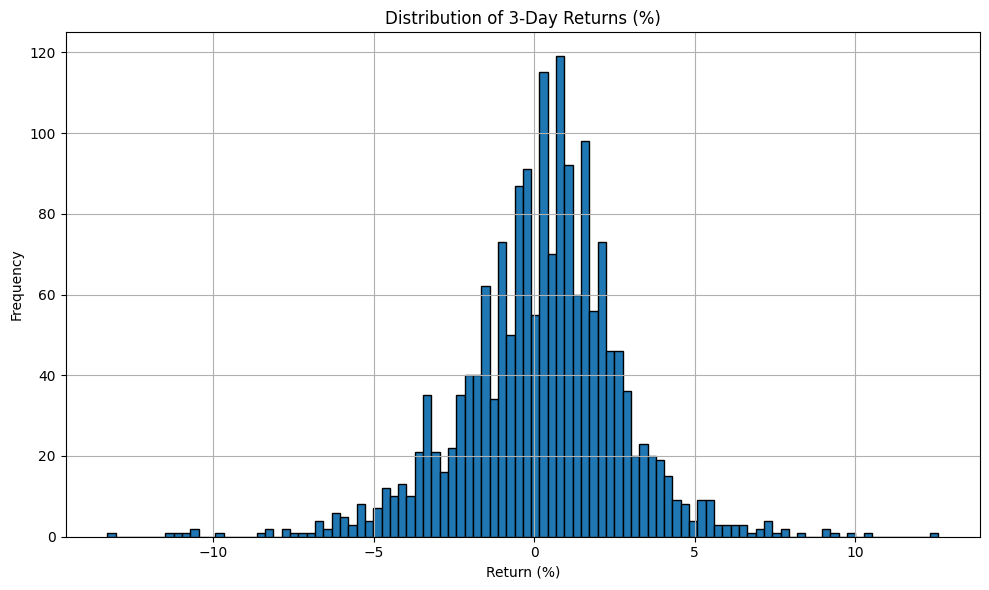

0.2   -1.8
0.4   -0.1
0.6    1.0
0.8    2.3
Name: Return%_4, dtype: float64


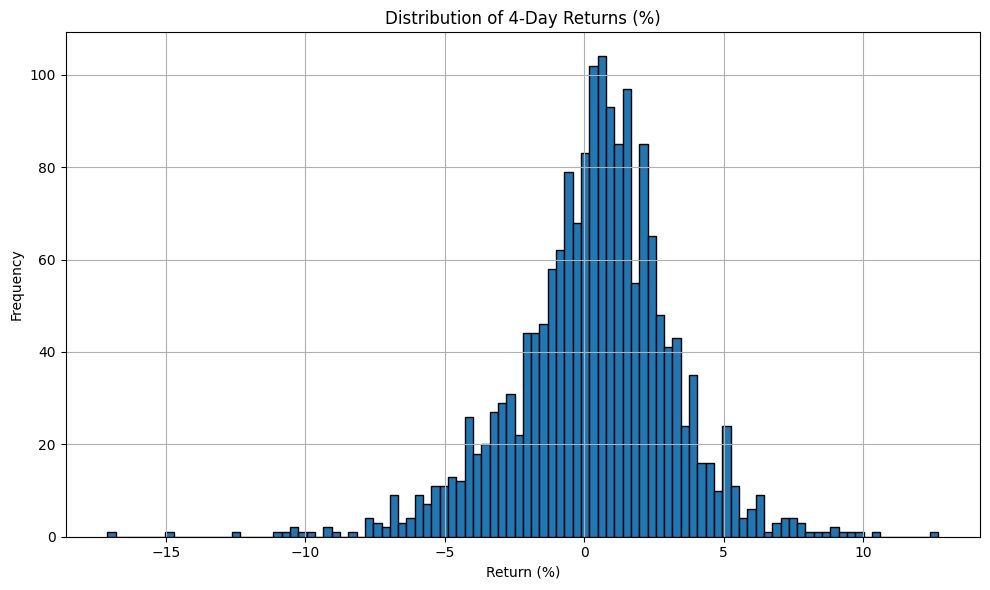

0.2   -1.9
0.4    0.0
0.6    1.2
0.8    2.7
Name: Return%_5, dtype: float64


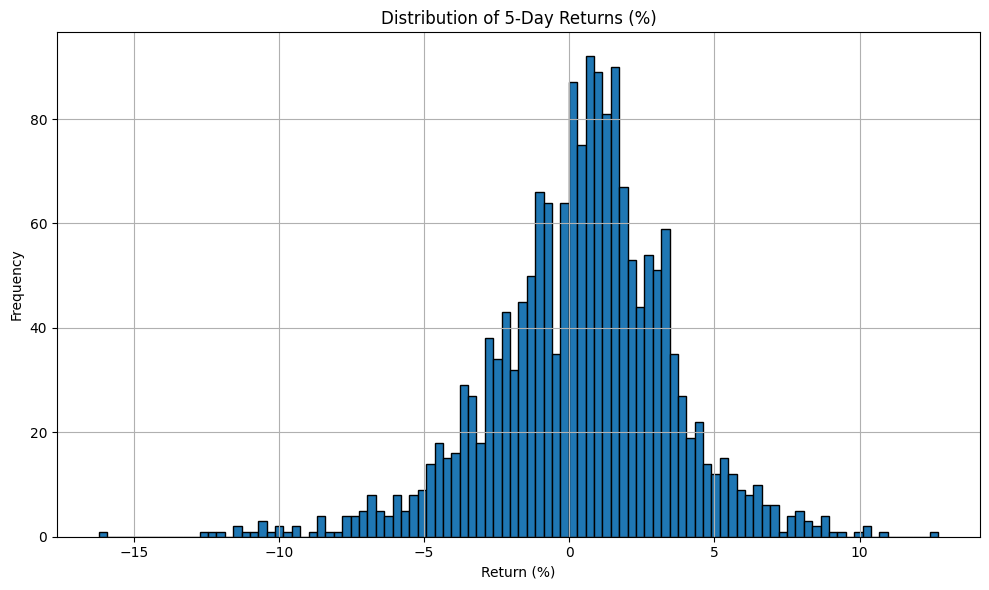

0.2   -1.9
0.4    0.0
0.6    1.4
0.8    3.0
Name: Return%_6, dtype: float64


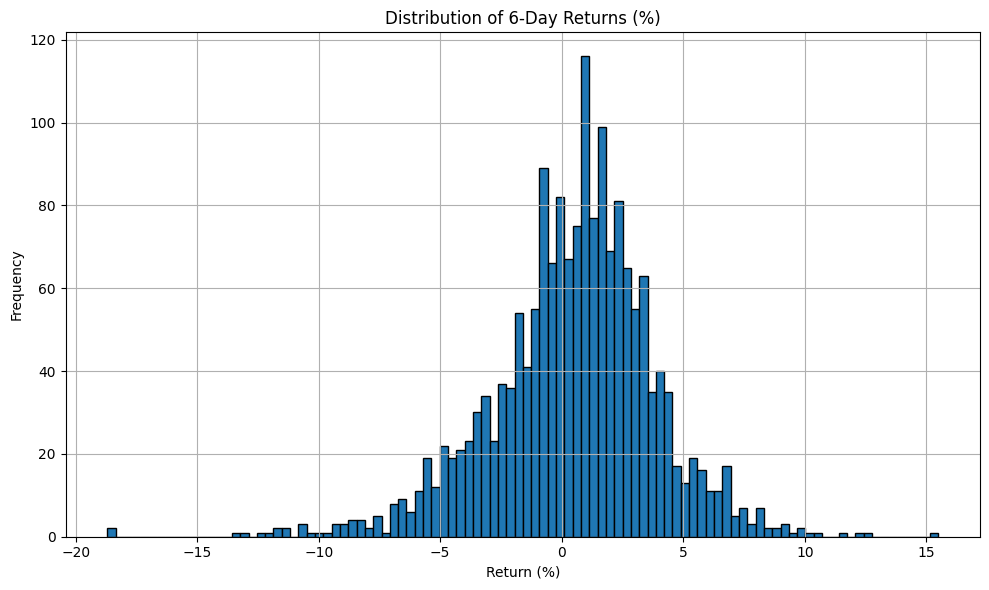

0.2   -2.1
0.4    0.1
0.6    1.6
0.8    3.3
Name: Return%_7, dtype: float64


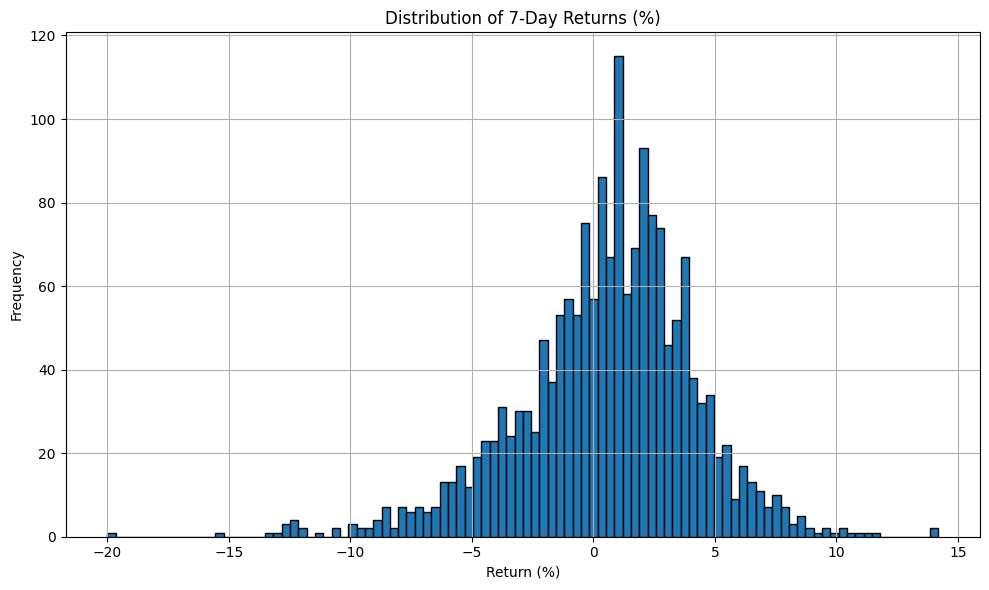

0.2   -2.2
0.4    0.3
0.6    1.8
0.8    3.5
Name: Return%_8, dtype: float64


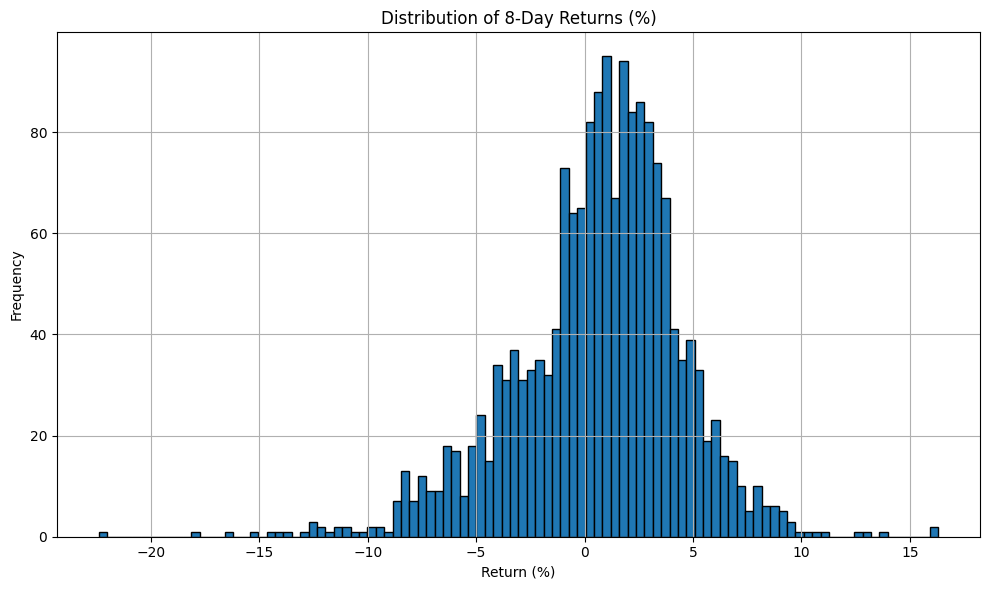

0.2   -2.4
0.4    0.4
0.6    2.0
0.8    3.7
Name: Return%_9, dtype: float64


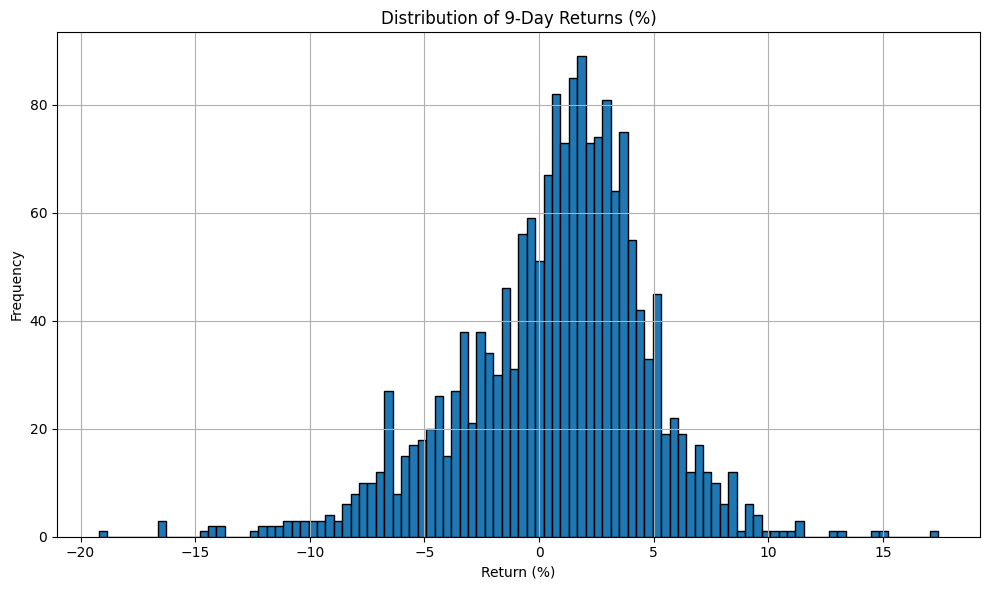

0.2   -2.6
0.4    0.5
0.6    2.2
0.8    4.0
Name: Return%_10, dtype: float64


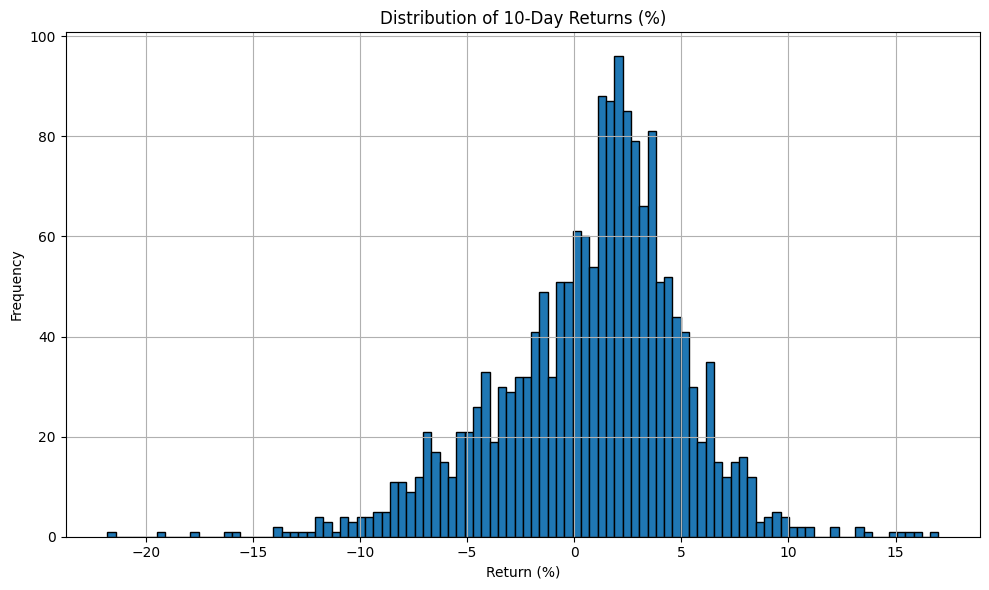

0.2   -3.2
0.4    0.9
0.6    3.0
0.8    5.1
Name: Return%_15, dtype: float64


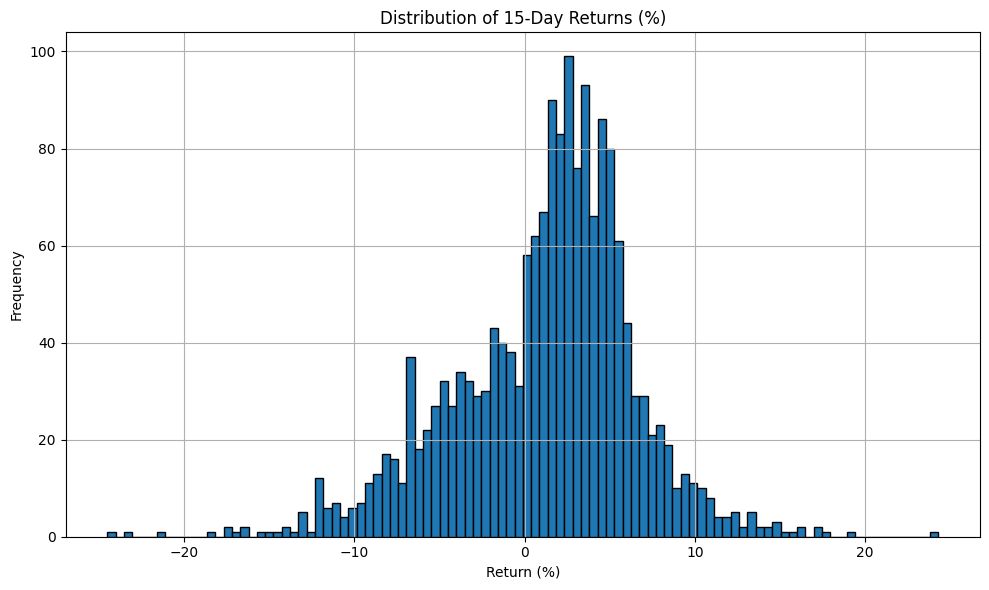

0.2   -3.62
0.4    1.10
0.6    3.80
0.8    6.10
Name: Return%_20, dtype: float64


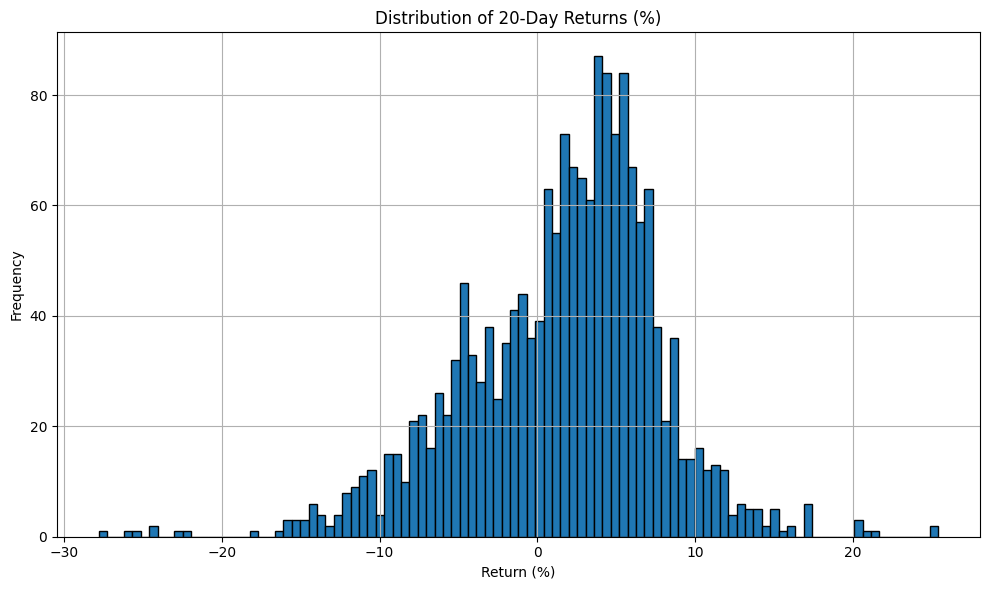

0.2   -3.62
0.4    1.00
0.6    4.30
0.8    7.20
Name: Return%_25, dtype: float64


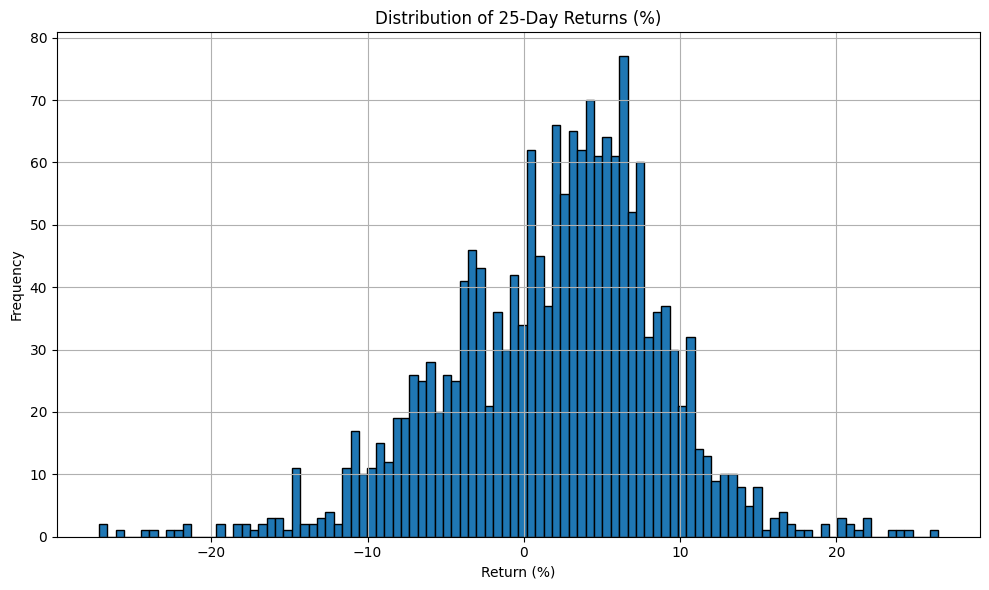

In [12]:
import matplotlib.pyplot as plt

for r in returns:

    quantiles = df[f'Return%_{r}'].quantile([0.2, 0.4, 0.6, 0.8])
    print(quantiles)
    plt.figure(figsize=(10, 6))
    df[f'Return%_{r}'].hist(bins=100, edgecolor='black')
    plt.title(f'Distribution of {r}-Day Returns (%)')
    plt.xlabel('Return (%)')
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


# Start with must include columns (slope)

In [15]:
def print_metrics(metrics):
        for thresh, metric_values in metrics.items():
            print(f"  Threshold {thresh}: {metric_values}")
    
def optimize_ttv(df_indicators, df_predict, thresh, opt, scale_pos_weight, arch, test_size, val_size, perf_size, return_metrics=False):
    
    def train_and_evaluate(model, param_grid, X_train, X_val, y_train, y_val, X_test, y_test, opt, thresh):
        
        # Create a Stratified K-Fold object
        stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        # Perform Random Search
        random_search = RandomizedSearchCV(
            estimator=model,
            param_distributions=param_grid,  # Corrected from param_grid to param_distributions
            scoring=opt,
            cv=stratified_kfold,
            n_jobs=-1,
            n_iter=40,  # Adjust this based on how many random samples you want to try
            random_state=42  # Ensures reproducibility
        )

        random_search.fit(X_train, y_train, eval_set=[(X_val, y_val)],
        verbose=False)
        best_model = random_search.best_estimator_
        # Predict probabilities
        y_prob = best_model.predict_proba(X_test)
        postot = y_test.sum()
        negtot = len(y_test) - y_test.sum()

        # Evaluate metrics for each threshold
        metrics = {}
        for t in thresh:
            y_pred_thresh = (y_prob[:, 1] > t).astype(int)
            y_pred_thresh[y_prob[:, 0] > t] = 0
            filtered_indices = (y_prob[:, 1] > t) | (y_prob[:, 0] > t)

            if filtered_indices.sum() > 0:
                y_test_valid = y_test[filtered_indices]
                y_pred_valid = y_pred_thresh[filtered_indices]
                posprec = round(precision_score(y_test_valid, y_pred_valid, pos_label=1, zero_division=0), 2)
                negprec = round(precision_score(y_test_valid, y_pred_valid, pos_label=0, zero_division=0), 2)
                poscnt = sum(y_pred_valid == 1)
                negcnt = sum(y_pred_valid == 0)
                posrec = round(posprec * poscnt / postot, 2)
                negrec = round(negprec * negcnt / negtot, 2)
                metrics[t] = {
                    'TT_Len': len(df_indicators),
                    "PosTot": postot,  
                    "NegTot": negtot,  
                    "PosRec": posrec,
                    'PosPrec': posprec,  
                    "NegRec": negrec,
                    'NegPrec': negprec,  
                    'PosFb': round((3*posprec*posrec)/((2*posrec)+(1*posprec)),3),
                    'NegFb': round((3*negprec*negrec)/((2*negrec)+(1*negprec)),3),
                }

        del random_search
        gc.collect()

        return metrics, best_model

    if arch == 'shallow':
        # Shallow
        xgboost_hyperparameters = {
            'scale_pos_weight': [scale_pos_weight],
            'n_estimators': [200, 300],
            'max_depth': [5, 7], 
            'learning_rate': [0.01],
            'subsample': [0.65],
            'colsample_bytree': [0.6], 
            'gamma': [0.2, 0.4],
            'alpha': [0.1, 1], 
            'lambda': [1, 2, 5], 
            'min_child_weight': [12, 15],
            'early_stopping_rounds': [10]
        }

    elif arch == 'moderate':

        # Moderate
        xgboost_hyperparameters = {
            'scale_pos_weight': [scale_pos_weight],
            'n_estimators': [300, 400],
            'max_depth': [7, 9], 
            'learning_rate': [0.01],
            'subsample': [0.65, .75],
            'colsample_bytree': [0.6, 0.7], 
            'gamma': [0.2, 0.3],
            'alpha': [0.1, 1], 
            'lambda': [1, 2, 5], 
            'min_child_weight': [9, 11],
            'early_stopping_rounds': [8]
        }

    else:

        # Deep
        xgboost_hyperparameters = {
            'scale_pos_weight': [scale_pos_weight],
            'n_estimators': [300, 400, 500],
            'max_depth': [8, 10, 12], 
            'learning_rate': [0.01],
            'subsample': [0.75, .85],
            'colsample_bytree': [0.75, 0.85], 
            'gamma': [0.1, 0.2],
            'alpha': [0.1, 1], 
            'lambda': [1, 2, 5], 
            'min_child_weight': [7, 9],
            'early_stopping_rounds': [10]
        }
        
    X_test = df_indicators.iloc[:perf_size].copy()
    y_test = df_predict.iloc[:perf_size].copy()
    df_indicators = df_indicators.iloc[test_size:].copy()
    df_predict = df_predict.iloc[test_size:].copy()

    X_val = df_indicators.iloc[:val_size].copy()
    y_val = df_predict.iloc[:val_size].copy()
    X_train = df_indicators.iloc[val_size:].copy()
    y_train = df_predict.iloc[val_size:].copy()

    # Train and evaluate models
    xg_metrics, best_xg_model = train_and_evaluate(XGBClassifier(random_state=42), xgboost_hyperparameters, X_train, X_val, y_train, y_val, X_test, y_test, opt, thresh)
    #record_validation_metrics(xg_metrics, arch='shallow', horizon=r, model_name=name)
    #savearch(best_xg_model, r, name, arch)
    metrics = list(xg_metrics.values())[0]
    pscore = metrics.get('PosFb', 0)
    nscore = metrics.get('NegFb', 0)

    #if pscore > .6 and nscore > .6:
    print_metrics(xg_metrics)

    if return_metrics:
        return xg_metrics, best_xg_model
    else:
        #print_metrics(xg_metrics)
        return best_xg_model
    
def save(best_model, days, model, ticker, arch):
    
    directory = f'../Models/Ensemble_{ticker}'  # Saves to the current working directory
    os.makedirs(directory, exist_ok=True)
    
    with open(os.path.join(directory, str(model)+'_xgboost_'+str(days)+str(arch)+'.pkl'), 'wb') as file_object:
        pickle.dump(best_model, file_object)

    print('Models Saved for '+(ticker)+'_'+str(model)+' '+str(days)+'_'+' Returns')

In [16]:
raw_all = tags['Indicator'][tags['Type'] == 'Raw'].tolist()

# By category × velocity
raw_duration_slow = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'duration') & (tags['velocity_25_cat_local'] == 'slow')]['Indicator'].tolist()
raw_duration_moderate = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'duration') & (tags['velocity_25_cat_local'] == 'moderate')]['Indicator'].tolist()
raw_duration_fast = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'duration') & (tags['velocity_25_cat_local'] == 'fast')]['Indicator'].tolist()

raw_trend_slow = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend') & (tags['velocity_25_cat_local'] == 'slow')]['Indicator'].tolist()
raw_trend_moderate = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend') & (tags['velocity_25_cat_local'] == 'moderate')]['Indicator'].tolist()
raw_trend_fast = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend') & (tags['velocity_25_cat_local'] == 'fast')]['Indicator'].tolist()

raw_trend_ratio_slow = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend_ratio') & (tags['velocity_25_cat_local'] == 'slow')]['Indicator'].tolist()
raw_trend_ratio_moderate = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend_ratio') & (tags['velocity_25_cat_local'] == 'moderate')]['Indicator'].tolist()
raw_trend_ratio_fast = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'trend_ratio') & (tags['velocity_25_cat_local'] == 'fast')]['Indicator'].tolist()

raw_volatility_slow = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'volatility') & (tags['velocity_25_cat_local'] == 'slow')]['Indicator'].tolist()
raw_volatility_moderate = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'volatility') & (tags['velocity_25_cat_local'] == 'moderate')]['Indicator'].tolist()
raw_volatility_fast = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'volatility') & (tags['velocity_25_cat_local'] == 'fast')]['Indicator'].tolist()
raw_volatility_fast_25 = [f"{col}_EMA25" for col in raw_volatility_fast for w in windows]

raw_momentum_slow = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'momentum') & (tags['velocity_25_cat_local'] == 'slow')]['Indicator'].tolist()
raw_momentum_moderate = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'momentum') & (tags['velocity_25_cat_local'] == 'moderate')]['Indicator'].tolist()
raw_momentum_fast = tags[(tags['Type'] == 'Raw') & (tags['Category'] == 'momentum') & (tags['velocity_25_cat_local'] == 'fast')]['Indicator'].tolist()
raw_momentum_fast_25 = [f"{col}_EMA25" for col in raw_momentum_fast for w in windows]

import itertools

# 1) Map your 15 groups to their feature‐lists
group_cols = {
    'duration_slow': raw_duration_slow,
    'duration_moderate': raw_duration_moderate,
    'duration_fast': raw_duration_fast,
    'trend_slow': raw_trend_slow,
    'trend_moderate': raw_trend_moderate,
    'trend_fast': raw_trend_fast,
    'trend_ratio_slow': raw_trend_ratio_slow,
    'trend_ratio_moderate': raw_trend_ratio_moderate,
    'trend_ratio_fast': raw_trend_ratio_fast,
    'volatility_slow': raw_volatility_slow,
    'volatility_moderate': raw_volatility_moderate,
    #'volatility_fast': raw_volatility_fast,
    'momentum_slow': raw_momentum_slow,
    'momentum_moderate': raw_momentum_moderate,
    #'momentum_fast': raw_momentum_fast,
    'raw_momentum_fast_25': raw_momentum_fast_25,
    'raw_volatility_fast_25': raw_volatility_fast_25
}

group_names = list(group_cols.keys())

# 2) Generate all 5‐combos, filtering out any with >2 from one category
valid_combos = []
for combo in itertools.combinations(group_names, 4):
    # extract the category portion (everything before the last "_")
    cats = [name.rsplit('_', 1)[0] for name in combo]
    # ensure no category appears more than twice
    if all(cats.count(cat) <= 2 for cat in set(cats)):
        valid_combos.append(combo)

# 3) (Optional) Build a mapping from combo → flattened feature list
combos_features = {
    combo: [feat for grp in combo for feat in group_cols[grp]]
    for combo in valid_combos
}

print(len(combos_features))

1329


0.2   -1.9
0.4    0.0
0.6    1.2
0.8    2.7
Name: Return%_5, dtype: float64
0.2   -2.2
0.4    0.4
0.6    1.5
0.8    2.9
Name: Return%_5, dtype: float64


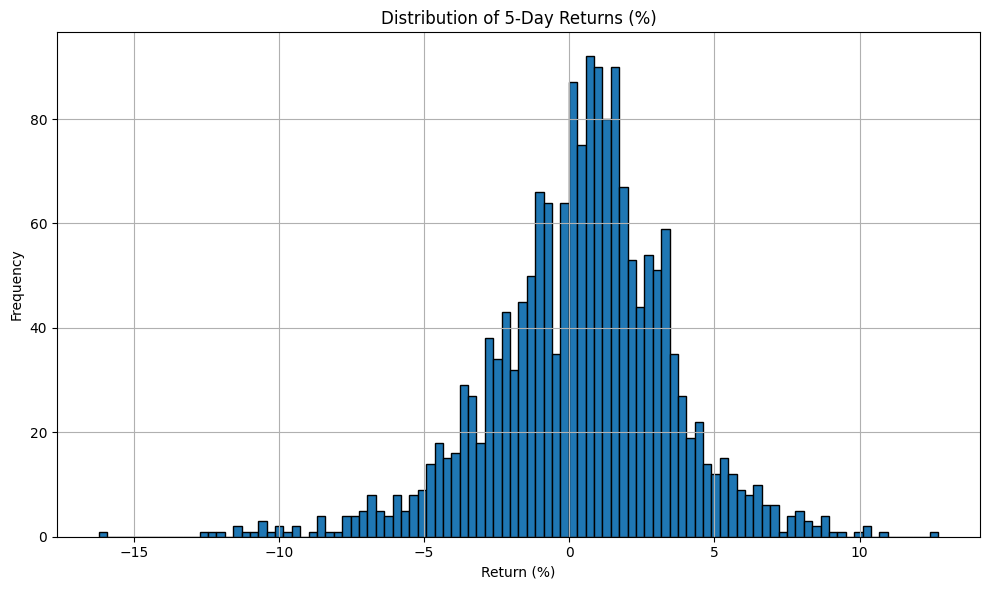

0.2   -3.2
0.4    0.9
0.6    3.0
0.8    5.1
Name: Return%_15, dtype: float64
0.2   -3.5
0.4    1.3
0.6    3.2
0.8    5.1
Name: Return%_15, dtype: float64


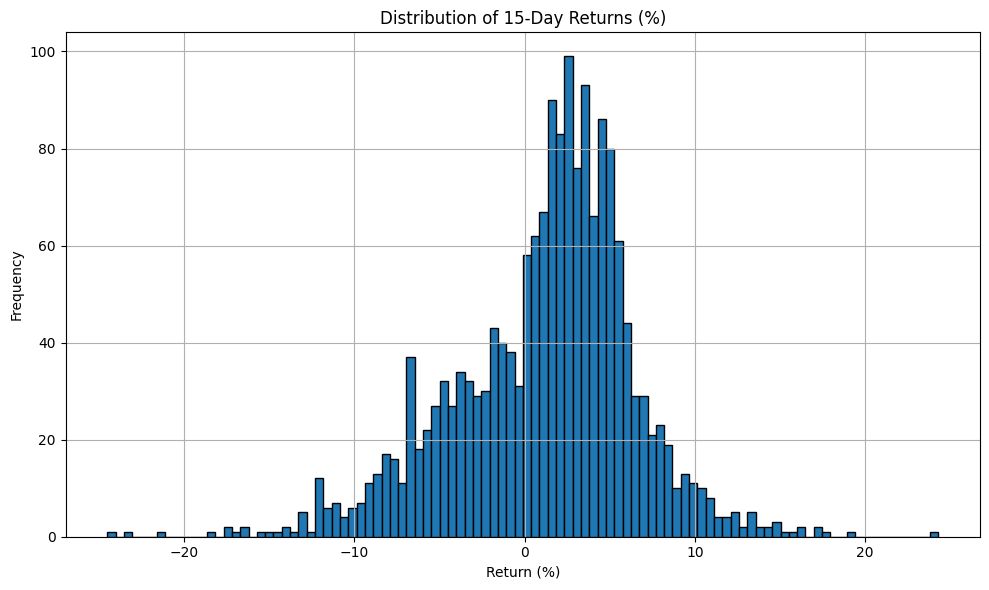

0.2   -3.62
0.4    1.00
0.6    4.30
0.8    7.20
Name: Return%_25, dtype: float64
0.2   -3.8
0.4    1.4
0.6    4.4
0.8    7.3
Name: Return%_25, dtype: float64


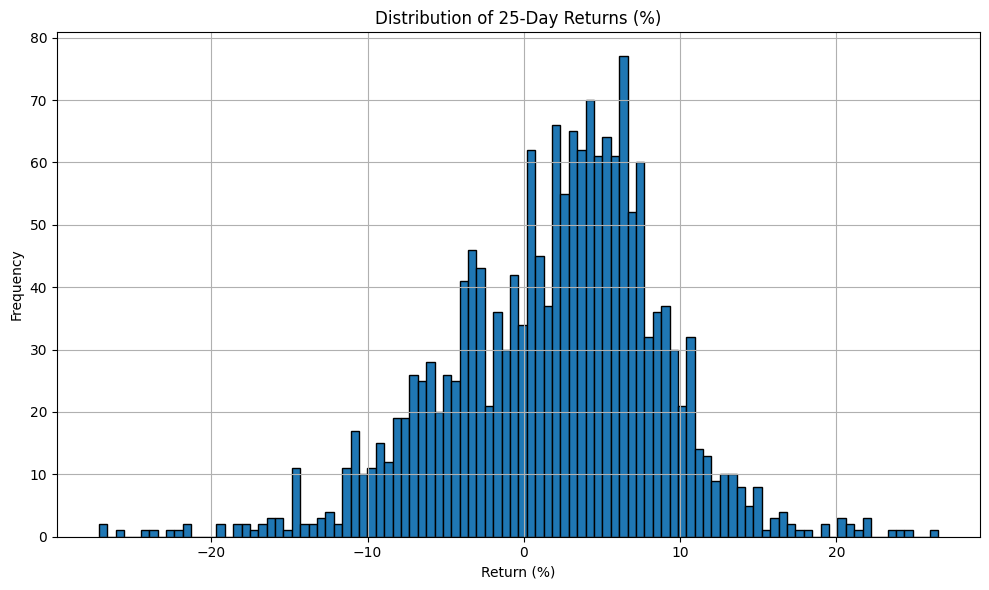

In [18]:
tickers = ['QQQ']#, 'NVDA', "AAPL", "MSFT", "TSLA", "AMZN", "AVGO", "META", "GOOGL", "COST", "NFLX"]
thresh = [.5]
arch_types = ['deep']#['deep', 'moderate', 'shallow']
n = len(raw_all)
results = []
lb = 8
returns = [1, 2, 3, 4, 5, 6, 8, 10, 15, 20, 25, 30, 45, 60, 75, 90]
name_to_combo = { " + ".join(c): c for c in valid_combos }
df = extract('QQQ', returns, lb, raw_all, windows=[25])

for ticker in tickers:

    if ticker == 'QQQ':
            returns = [5, 15, 25]#[4, 5, 6, 8, 10, 15, 20, 25, 30, 45, 60, 75, 90]
    else:
        returns = [4, 6, 8, 10, 15]

    for r in returns:
        quantiles = df[f'Return%_{r}'].quantile([0.2, 0.4, 0.6, 0.8])
        print(quantiles)

        filtered = df[(df[f'Return%_{r}'] < -0.3) | (df[f'Return%_{r}'] > 0.3)]
        quantiles = filtered[f'Return%_{r}'].quantile([0.2, 0.4, 0.6, 0.8])
        print(quantiles)

        plt.figure(figsize=(10, 6))
        df[f'Return%_{r}'].hist(bins=100, edgecolor='black')
        plt.title(f'Distribution of {r}-Day Returns (%)')
        plt.xlabel('Return (%)')
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.tight_layout()
        plt.show()
         

In [ ]:
tickers = ['QQQ']#, 'NVDA', "AAPL", "MSFT", "TSLA", "AMZN", "AVGO", "META", "GOOGL", "COST", "NFLX"]
thresh = [.5]
arch_types = ['deep']#['deep', 'moderate', 'shallow']
n = len(raw_all)
results = []
lb = 8
returns = [1, 2, 3, 4, 5, 6, 8, 10, 15, 20, 25, 30, 45, 60, 75, 90]
name_to_combo = { " + ".join(c): c for c in valid_combos }
df = extract('QQQ', returns, lb, raw_all, windows=[25])

for ticker in tickers:

    if ticker == 'QQQ':
            returns = [5, 15, 25]#[4, 5, 6, 8, 10, 15, 20, 25, 30, 45, 60, 75, 90]
    else:
        returns = [4, 6, 8, 10, 15]

    for r in returns:
            
        for combo in valid_combos:

            combo_name = "+".join(combo)
            cols = combos_features[combo]
            
            #df = extract(ticker, returns, lb, cat_cols_all, windows=[10, 25])
            df_ph = df.copy()
            df_ph = df_ph.iloc[r:].copy()
            return_col = f"Return_{r}"
            model_key = f"QQQ_{r}"
            counts = df_ph[return_col].value_counts()
            neg = counts.get(0, 0)
            pos = counts.get(1, 1)  # prevent division by zero
            scale_pos_weight = neg / pos

            for arch in arch_types:

                # Choose evaluation metric
                opt = 'matthews_corrcoef'

                # Combine features with return column, drop missing
                #cols += ['Close_slope10', 'Close_slope25', 'Close_slope50']
                used_cols = cols + [return_col]
                df_model = df_ph[used_cols].dropna()
                #print(df_ph['Date'].iloc[0])
                
                df_indicators = df_model[cols]
                df_indicators = df_indicators.replace([np.inf, -np.inf], 0)
                df_predict = df_model[return_col]
                test_size = 100 
                val_size = 300
                perf_size = 100
                
                print(f"Results for {combo_name} | {arch} | {ticker}_{r}")
                xg_metrics, best_xg_model = optimize_ttv(df_indicators, df_predict, thresh, opt, scale_pos_weight, arch, test_size, val_size, perf_size, return_metrics=True)
                metrics = list(xg_metrics.values())[0]
                row = {'name': combo_name, 'arch': arch, 'ticker': ticker, 'horizon': r, 'val_size': val_size, **metrics}
                results.append(row)
                """
                pscore = metrics.get('PosFb', 0)
                nscore = metrics.get('NegFb', 0)
                # build one flat record
                if pscore >= .8 and nscore >= .8:
                    row = {'name': combo_name, 'arch': arch, 'ticker': ticker, 'horizon': r, 'val_size': val_size, **metrics}
                    results.append(row)
                """
                print('---------------------------')